                 PC1       PC2       PC3       PC4       PC5       PC6  \
 RedMeat   -0.302609 -0.056252  0.297580  0.646477  0.322160 -0.459870   
 WhiteMeat -0.310556 -0.236853 -0.623897 -0.036992 -0.300165 -0.121007   
 Eggs      -0.426679 -0.035336 -0.181528  0.313164  0.079110  0.361249   
 Milk      -0.377727 -0.184589  0.385658 -0.003318 -0.200414  0.618438   
 Fish      -0.135650  0.646820  0.321274 -0.215955 -0.290031 -0.136791   
 Cereals    0.437743 -0.233485 -0.095918 -0.006204  0.238168  0.080758   
 Starch    -0.297248  0.352826 -0.242975 -0.336685  0.735973  0.147667   
 Nuts       0.420334  0.143311  0.054388  0.330288  0.150537  0.447010   
 Fr&Veg     0.110420  0.536190 -0.407556  0.462056 -0.233517  0.118550   

                 PC7       PC8       PC9  
 RedMeat    0.150334  0.019858 -0.246000  
 WhiteMeat -0.019664  0.027876 -0.592397  
 Eggs      -0.443272  0.491200  0.333386  
 Milk       0.462095 -0.081422 -0.178084  
 Fish      -0.106394  0.448732 -0.312826  
 

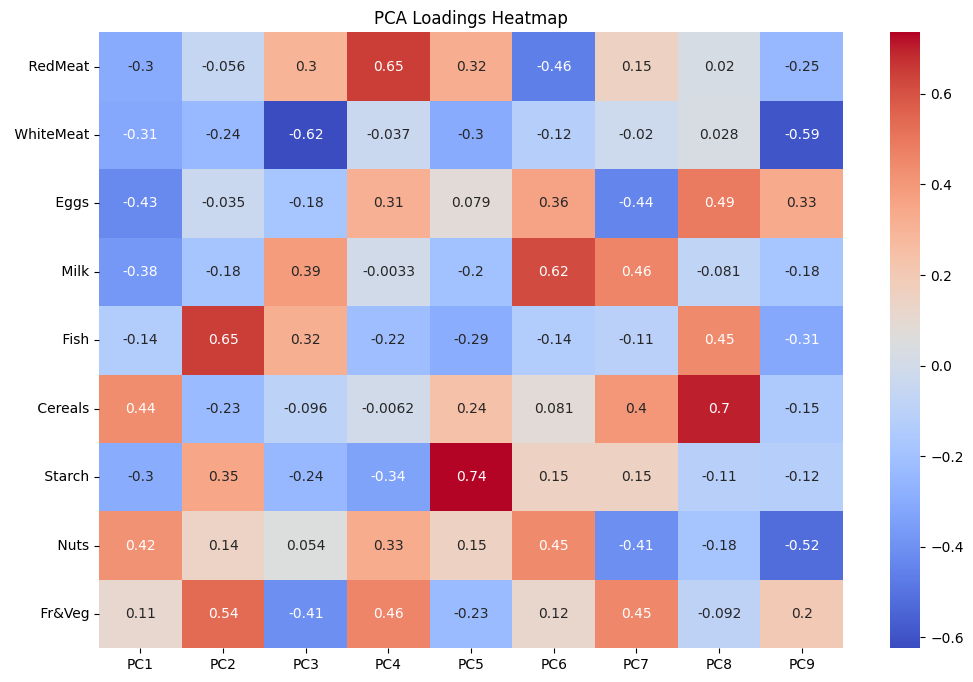

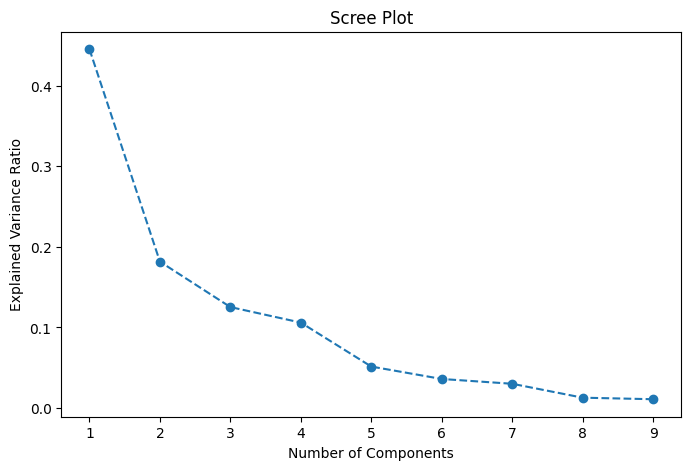

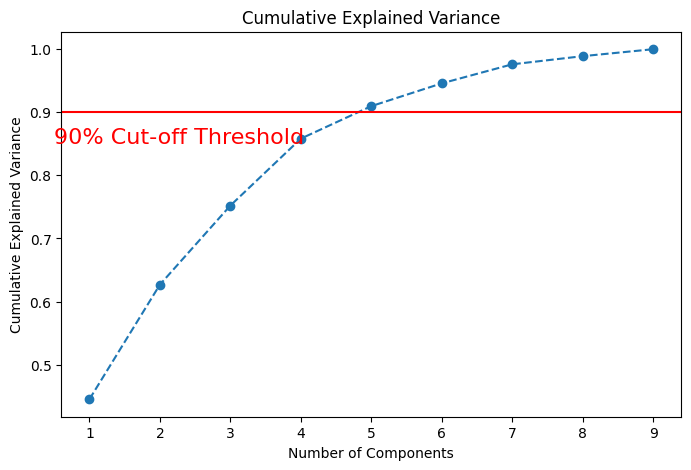

KeyError: "['Id'] not found in axis"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns

# Load the protein dataset
url = "https://raw.githubusercontent.com/fenago/datasets/main/protein.csv"
food_data = pd.read_csv(url)

# Standardize the Data
scaler = StandardScaler()
food_scaled = scaler.fit_transform(food_data.iloc[:, 1:])

# Apply PCA
pca = PCA()
principal_components = pca.fit_transform(food_scaled)

# Analyze Principal Components
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i}' for i in range(1, len(food_data.columns))], index=food_data.columns[1:])
print(loadings)

# Identify important features for each Principal Component
threshold = 0.3
important_features = {}
for column in loadings.columns:
    important_features[column] = loadings.index[loadings[column].abs() > threshold].tolist()

# Print important features
for pc, features in important_features.items():
    print(f"{pc}: {', '.join(features)}")

# Create a heatmap for the loadings
plt.figure(figsize=(12, 8))
sns.heatmap(loadings, annot=True, cmap='coolwarm')
plt.title('PCA Loadings Heatmap')
plt.show()

# Create a scree plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.show()

# Calculate cumulative explained variance
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Create a plot for cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.9, color='r', linestyle='-')  # 90% variance line
plt.text(0.5, 0.85, '90% Cut-off Threshold', color='red', fontsize=16)
plt.show()
# Load the Iris dataset
iris_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv"
iris = pd.read_csv(iris_url, header=None)
# Remove header=None so that the first row is read as column names
iris.columns = ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Species']



# Convert species names to numerical labels
le = LabelEncoder()
iris['Species'] = le.fit_transform(iris['Species'])

# Drop the Id column
iris = iris.drop('Id', axis=1)

# Prepare features and labels
X = iris.iloc[:, :-1].values
y = iris.iloc[:, -1].values  # Using the last column for labels

# Perform PCA for Iris dataset
pca_iris = PCA(n_components=3)
X_pca_iris = pca_iris.fit_transform(X)

# Create a 3D scatter plot for Iris dataset
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Define species names for labeling
species_names = ['Setosa', 'Versicolor', 'Virginica']
for name, label in zip(species_names, range(len(species_names))):
    ax.text(X_pca_iris[y == label, 0].mean(),
            X_pca_iris[y == label, 1].mean() + 1.5,
            X_pca_iris[y == label, 2].mean(), name,
            horizontalalignment='center',
            bbox=dict(alpha=0.5, edgecolor='w', facecolor='w'))

# Reorder labels for color mapping
y_colored = np.choose(y, [1, 2, 0])
ax.scatter(X_pca_iris[:, 0], X_pca_iris[:, 1], X_pca_iris[:, 2], c=y_colored, cmap=plt.cm.nipy_spectral, edgecolor='k')

# Hide tick labels for a cleaner look
ax.w_xaxis.set_ticklabels([])
ax.w_yaxis.set_ticklabels([])
ax.w_zaxis.set_ticklabels([])

# Show the plot
plt.title("PCA of Iris Dataset")
plt.show()
